In [1]:
import gdsfactory as gf
gf.gpdk.PDK.activate()

In [2]:
from upvfab.sin300.cband import PDK, cells

Objective: Finalize the full die layout with test structures for fabrication.
Steps:
1. Integrate the wvl tracker layout with input/output connections.
2. Add test structures (e.g., waveguides, and mmis)
to enable characterization of the filter.
3. Export the final .GDS file for submission and verification

In [9]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

In [10]:
main = gf.Component()
die_ref = main << die(dieW = dieW, layer_box = "FLOORPLAN")

## DEFINICIÓN MMI3X3: basado en definición 2x2 gds


    Schematic:

                    length_mmi
                     <------>
                     ________
                  __/        \__  o4
             o3  __          __
                   \        /
                  __/        \__  o5
             o2  __          __
                   \        /
                  __/        \__  o6
             o1  __          __
                   \________/

In [11]:
from gdsfactory.component import Component
from gdsfactory.typings import CrossSectionSpec, ComponentSpec


@gf.cell
def mmi3x3(
    width: float | None = None,
    width_taper: float = 1.0,
    length_taper: float = 10.0,
    length_mmi: float = 20.0,
    width_mmi: float = 6.0,
    gap_mmi: float = 0.25,
    taper: ComponentSpec = gf.components.taper,
    straight: ComponentSpec = gf.components.straight,
    cross_section: CrossSectionSpec = "strip",
) -> Component:
    c = gf.Component()

    gap_mmi = gf.snap.snap_to_grid(gap_mmi, grid_factor=2) #ajusta el gap a la rejilla para evitar decimales raros que queden fuera del grid

    x = gf.get_cross_section(cross_section)
    width = width or x.width
    w_taper = width_taper

    _taper = gf.get_component(
        taper,
        length=length_taper,
        width1=width,
        width2=w_taper,
        cross_section=cross_section,
    )

    pitch = w_taper + gap_mmi

    y_bot = -pitch
    y_mid = 0
    y_top = +pitch

    _ = c << gf.get_component(
        straight,
        length=length_mmi,
        width=width_mmi,
        cross_section=cross_section,
    )

    temp_component = Component() #para definir los puertos ideales (temporales)

    ports = [
        temp_component.add_port(
            name="o1",
            orientation=180,
            center=(0, y_bot),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o2",
            orientation=180,
            center=(0, y_mid),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o3",
            orientation=180,
            center=(0, y_top),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o4",
            orientation=0,
            center=(length_mmi, y_top),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o5",
            orientation=0,
            center=(length_mmi, y_mid),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o6",
            orientation=0,
            center=(length_mmi, y_bot),
            width=w_taper,
            cross_section=x,
        ),
    ]

    for port in ports:
        taper_ref = c << _taper
        taper_ref.connect(
            port="o2",
            other=port,
            allow_width_mismatch=True,
        )
        c.add_port(name=port.name, port=taper_ref.ports["o1"])

    c.flatten()
    return c

2026-04-28 11:05:22.087 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


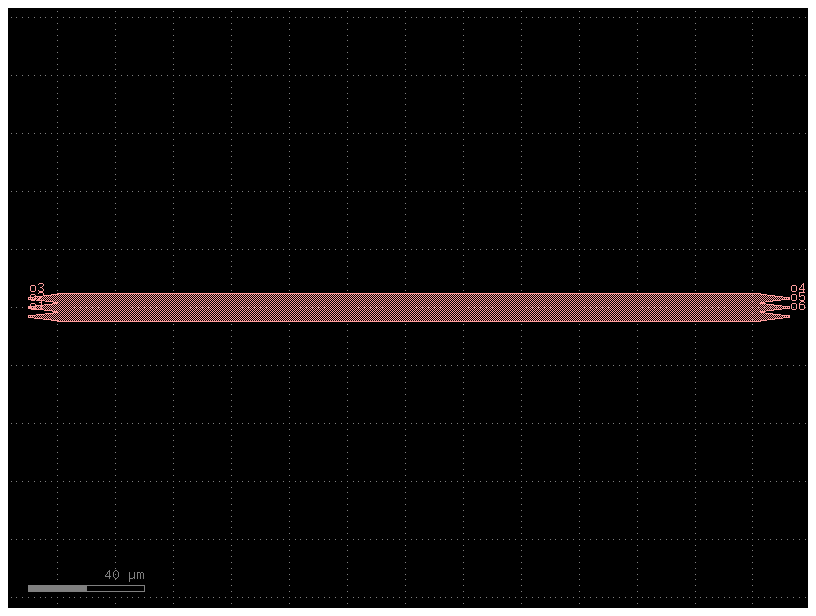

In [12]:
c = mmi3x3(width= 0.45, width_taper=2.9, length_taper= 10.0, length_mmi = 242.4723, width_mmi= 10, gap_mmi = 0.25)
c.draw_ports()
c.show()
c.plot()

## ESPIRAL: 

spiral_2 parece ser la mejor opción para interferometría, sin embargo para una guía tan larga (56 mm), da problemas porque hace que la guía del puerto de salida cruce por el medio. 

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/gdsfactory/components/bends/bend_euler.py:110: UserWarning: {'width': 0.5} ignored for cross_section 'strip'
  x = gf.get_cross_section(cross_section, width=width or x.width)


2026-04-28 11:05:27.590 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


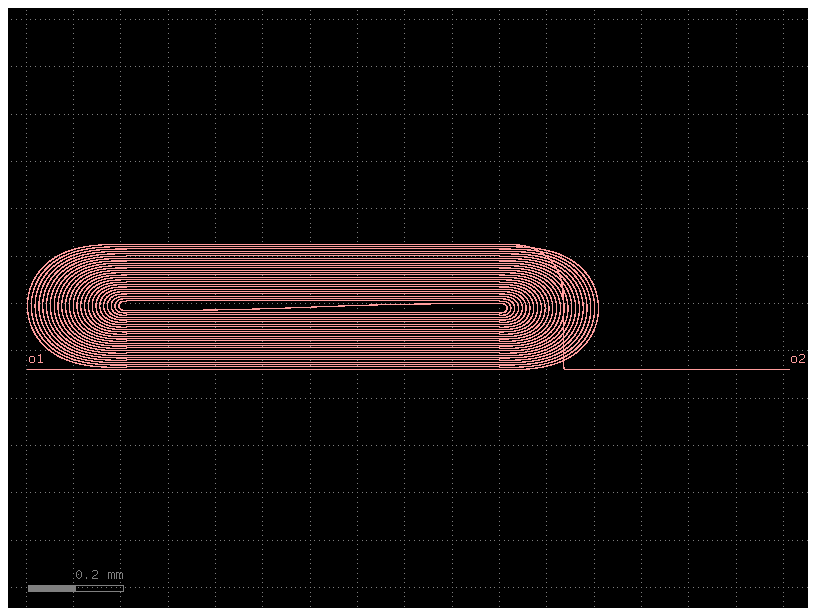

In [13]:
upper_arm_length = 1400
c = gf.components.spiral_racetrack_fixed_length(length=56000, in_out_port_spacing= upper_arm_length , n_straight_sections=50, min_spacing=5, bend='bend_euler', bend_s='bend_s', cross_section='strip')
c.draw_ports()
c.show()
c.plot()

2026-04-28 11:05:34.890 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


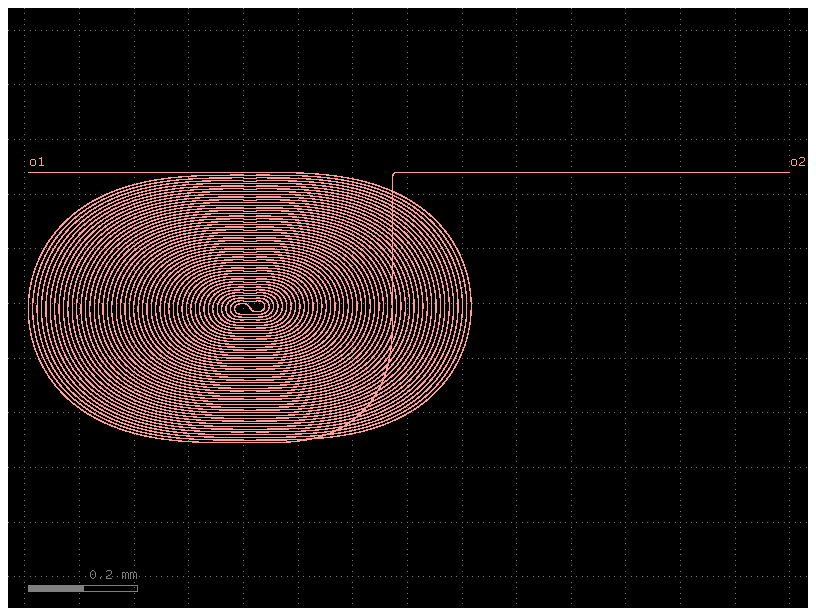

In [14]:
upper_arm_length = 1000
c = gf.components.spiral_racetrack_fixed_length(length=56000, in_out_port_spacing= upper_arm_length , n_straight_sections=96, min_spacing=5, bend='bend_euler', bend_s='bend_s', cross_section='strip')
c.draw_ports()
c.show()
c.plot()

In [10]:
"""
Spirals for cutback prop.loss measurement
DoE: Assuming 1dB/cm loss: 1.5cm difference between spirals mean 1.5dB difference between
measurements.
"""
from upvfab.sin300.cband.cells import define_spiral_length
rad = 120
N_spr = 7
dy_spr = 10
spiral_lengths = [56000,45000,30000,15000]  # in microns
spirals = []
calc = False
calc_lengths = [2733.76,
                1851.42,
                969.07,
                86.716]
for i, L in enumerate(spiral_lengths):
    if calc:
        length_spiral = define_spiral_length(delay_length=L,
                                                N_spr=N_spr,
                                                radius=rad,
                                                d_SPR=10,
                                                dy_SPR=dy_spr,
                                                )
    else:
        length_spiral = calc_lengths[i]
    spiral = cells.spiral_upv(
            radius=rad,
            N_spr=N_spr,
            d_SPR = 10,
            dy_SPR = dy_spr,
            dx_SPR = length_spiral,
            layer="strip",
            )
    print('Spiral length', spiral.info["length"])
    spirals.append(spiral)

Spiral length 59999.759
Spiral length 44999.979
Spiral length 30000.029000000002
Spiral length 15000.011


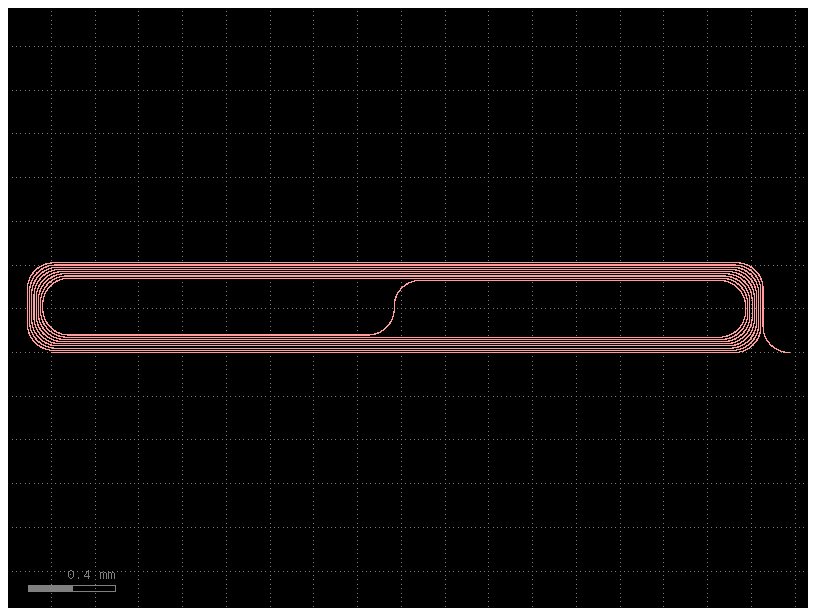

In [11]:
spirals[0].plot()